In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving hotel.csv to hotel.csv


In [ ]:
df = pd.read_csv("hotel.csv")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,7/3/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,9/6/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,9/7/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,9/7/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,9/7/2017


In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
df.shape

(119390, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.duplicated().sum()

np.int64(31994)

# 1🧹 Important Data Cleaning & Preprocessing Steps


In [ ]:
# REMOVE DUPLICATE RECORDS
df.duplicated().sum()   # Count duplicate rows
df.drop_duplicates(inplace=True)   # Remove duplicates permanently

Why :
Duplicates distort analysis and give wrong insights
In my case: ~ 31K duplicates removed

In [ ]:
# Handle Missing Values
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# company two much null values
df.drop(columns=['company'], inplace=True)
# Fill with logical values
df['agent'] = df['agent'].fillna(0)
# NO children
df['children'] = df['children'].fillna(0)
# countries
df['country'] = df['country'].fillna('Others')

In [ ]:
#  Remove Invalid Data (Very Important)
df = df[(df['adults'] + df['children'] + df['babies']) > 0].copy()
# Fix Data Types
df.loc[:, 'children'] = df['children'].astype(int)
df.loc[:, 'agent'] = df['agent'].astype(int)

<Axes: ylabel='adr'>

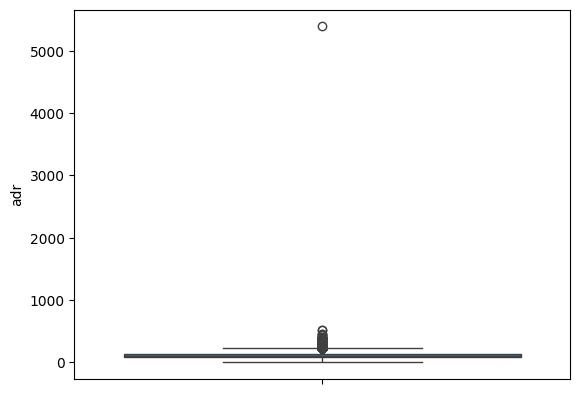

In [ ]:
# Handle Outliers (Important for ADR & Lead Time)
sns.boxplot(df['adr'])

In [ ]:
df = df[df['adr'] < 5000]

<Axes: ylabel='adr'>

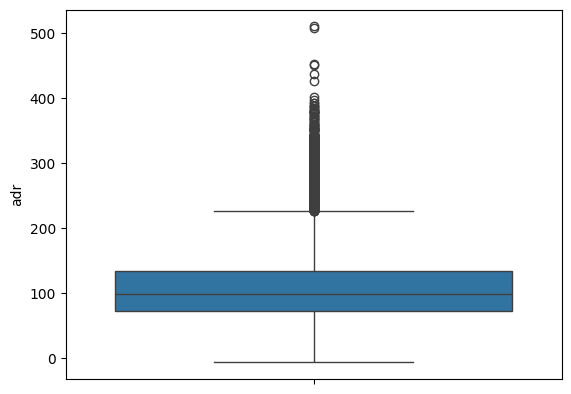

In [ ]:
sns.boxplot(df['adr'])

In [ ]:
# Feature Engineering (Very Important)
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['revenue'] = df['adr'] * df['total_nights']

In [ ]:
# Convert Categorical Labels (Optional but Useful)
df['is_canceled'] = df['is_canceled'].map({0:'Not Canceled', 1:'Canceled'})
df['is_repeated_guest'] = df['is_repeated_guest'].map({0:'No', 1:'Yes'})

In [ ]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,revenue
0,Resort Hotel,Not Canceled,342,2015,July,27,1,0,0,2,...,0,Transient,0.00,0,0,Check-Out,7/1/2015,2.0,0,0.00
1,Resort Hotel,Not Canceled,737,2015,July,27,1,0,0,2,...,0,Transient,0.00,0,0,Check-Out,7/1/2015,2.0,0,0.00
2,Resort Hotel,Not Canceled,7,2015,July,27,1,0,1,1,...,0,Transient,75.00,0,0,Check-Out,7/2/2015,1.0,1,75.00
3,Resort Hotel,Not Canceled,13,2015,July,27,1,0,1,1,...,0,Transient,75.00,0,0,Check-Out,7/2/2015,1.0,1,75.00
4,Resort Hotel,Not Canceled,14,2015,July,27,1,0,2,2,...,0,Transient,98.00,0,1,Check-Out,7/3/2015,2.0,2,196.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,Not Canceled,23,2017,August,35,30,2,5,2,...,0,Transient,96.14,0,0,Check-Out,9/6/2017,2.0,7,672.98
119386,City Hotel,Not Canceled,102,2017,August,35,31,2,5,3,...,0,Transient,225.43,0,2,Check-Out,9/7/2017,3.0,7,1578.01
119387,City Hotel,Not Canceled,34,2017,August,35,31,2,5,2,...,0,Transient,157.71,0,4,Check-Out,9/7/2017,2.0,7,1103.97
119388,City Hotel,Not Canceled,109,2017,August,35,31,2,5,2,...,0,Transient,104.40,0,0,Check-Out,9/7/2017,2.0,7,730.80


# Exploratory Data Analysis and Business Insights

# 1 HOTEL TYPE DISTRIBUTION

/tmp/ipykernel_4052/468837599.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hotel', data=df, palette=['#FF6B6B', '#4ECDC4'])


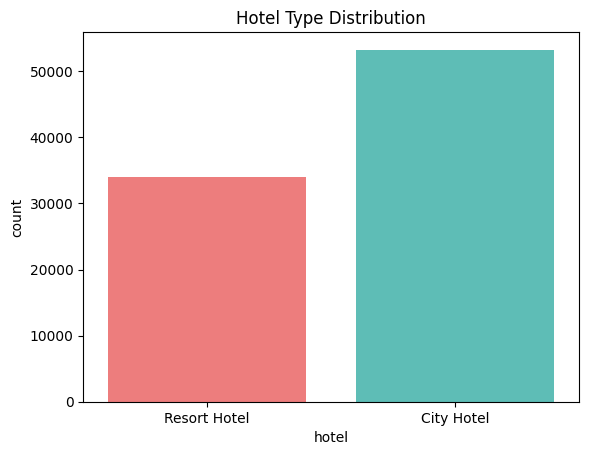

In [ ]:
sns.countplot(x='hotel', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Hotel Type Distribution')
plt.show()

Why: Compare hotel demand

Insight:  City Hotel has more bookings

Impact: Focus marketing & expansion on city hotels

# 2. CANCELLATION RATE

/tmp/ipykernel_4052/3061788410.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette=['#2ECC71', '#E74C3C'])


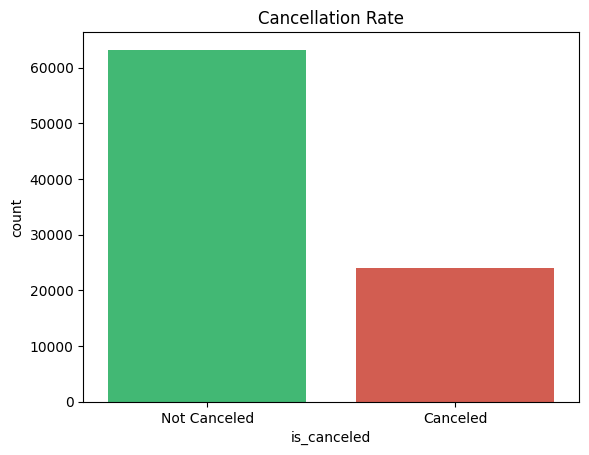

In [ ]:
sns.countplot(x='is_canceled', data=df, palette=['#2ECC71', '#E74C3C'])
plt.title('Cancellation Rate')
plt.show()

Why: Understand cancellation volume

Insight: Significant cancellations exist

Impact: Revenue leakage → needs control strategy

# 3. LEAD TIME DISTRIBUTION

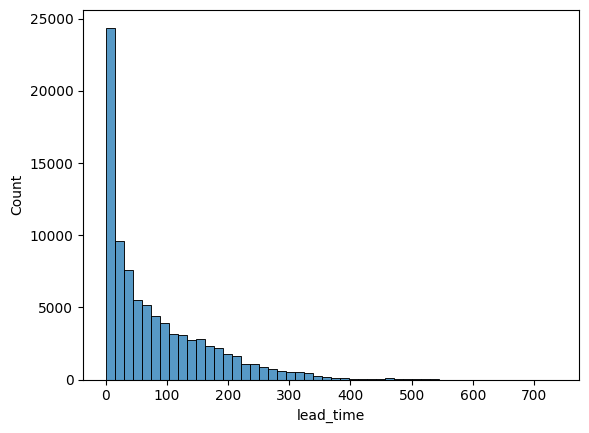

In [ ]:
sns.histplot(df['lead_time'], bins=50)
plt.show()

Why: Understand booking timing

Insight: Many bookings are made far in advance

Impact: Early bookings → higher cancellation risk

# 4. LEAD TIME VS CANCELLATION

/tmp/ipykernel_4052/4107616106.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_canceled', y='lead_time', data=df, palette=['#27AE60', '#C0392B'])


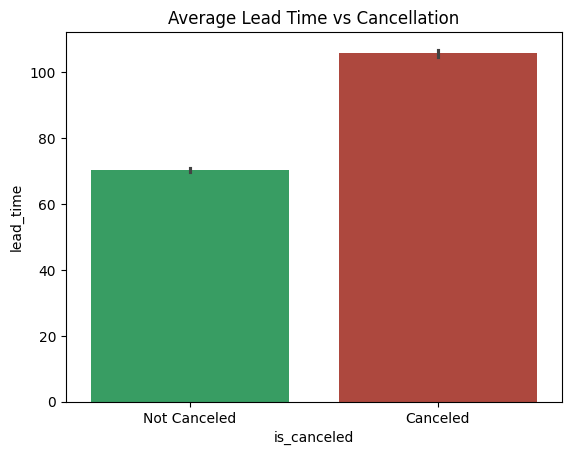

In [ ]:
sns.barplot(x='is_canceled', y='lead_time', data=df, palette=['#27AE60', '#C0392B'])
plt.title('Average Lead Time vs Cancellation')
plt.show()

Why: Relationship analysis

Insight: Longer lead time → more cancellations

Impact: Use lead time for prediction models

# 5. MONTHLY BOOKING TREND

/tmp/ipykernel_4052/3205346062.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


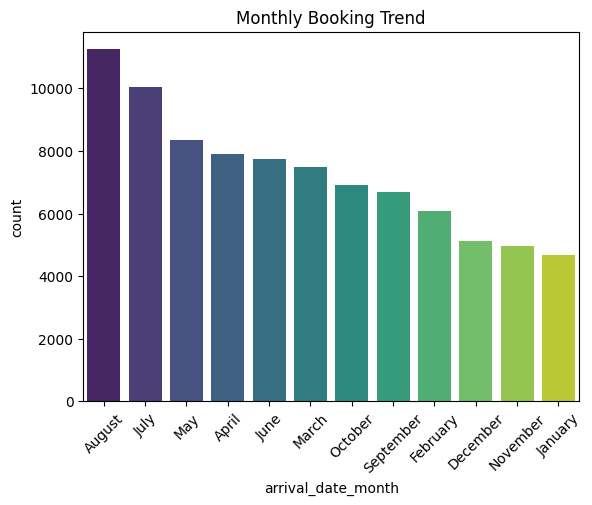

In [ ]:
sns.countplot(
    x='arrival_date_month',
    data=df,
    order=df['arrival_date_month'].value_counts().index,
    palette='viridis'
)

plt.title('Monthly Booking Trend')
plt.xticks(rotation=45)
plt.show()

Why: Identify seasonality

Insight: Peak bookings in July–August

Impact: Dynamic pricing & resource planning

# 6. ADR DISTRIBUTION

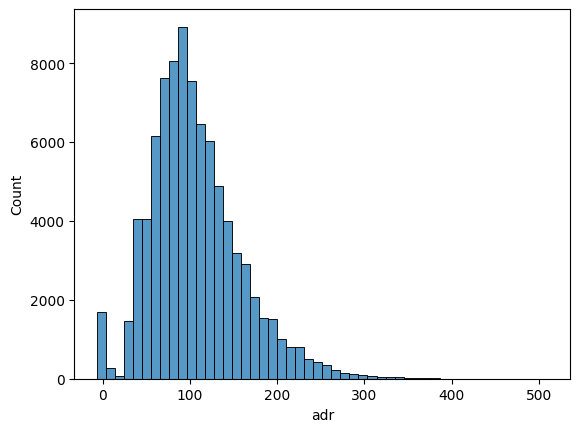

In [ ]:
sns.histplot(df['adr'], bins=50)
plt.show()

Why: Analyze pricing

Insight: Most bookings are mid-price range

Impact: Pricing optimization

# 7.  Market Segment Distribution

/tmp/ipykernel_4052/4284002086.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


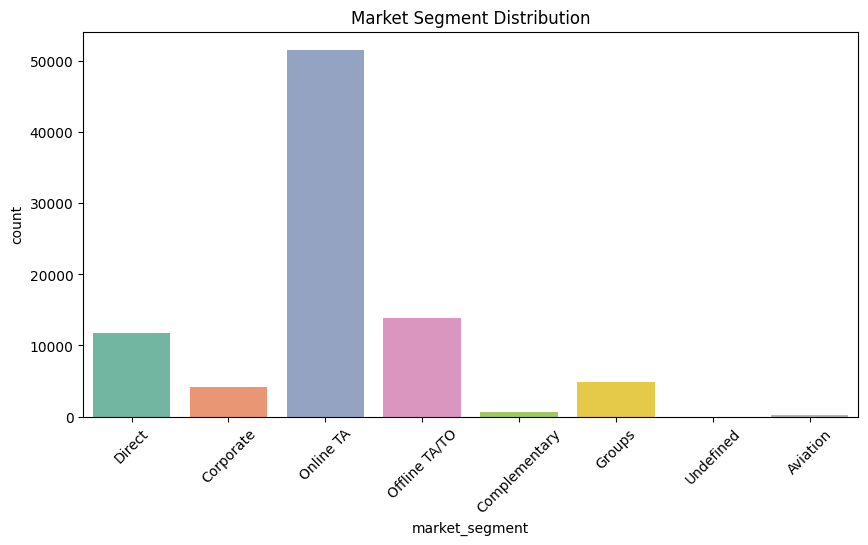

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='market_segment',
    data=df,
    palette='Set2'   # Different color for each bar
)

plt.xticks(rotation=45)
plt.title("Market Segment Distribution")
plt.show()

Why: Customer segmentation

Insight: Online (TA/TO) dominates

Impact: Focus digital channels

# 8. Deposit Type vs Cancellation

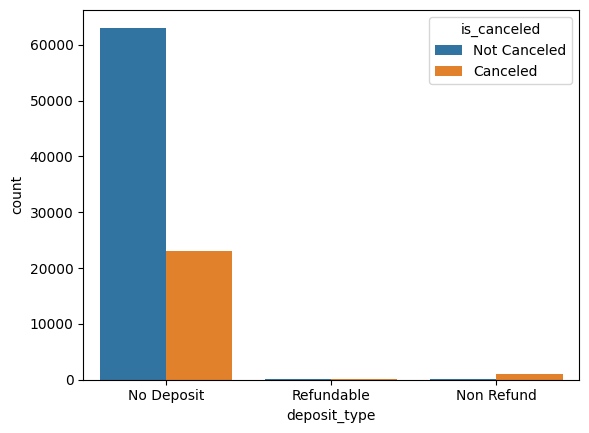

In [ ]:
sns.countplot(x='deposit_type', hue='is_canceled', data=df)
plt.show()

Why: Policy analysis

Insight: No deposit → high cancellation

Impact: Introduce deposit strategy

# 9. Repeated Guests

/tmp/ipykernel_4052/2711248103.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


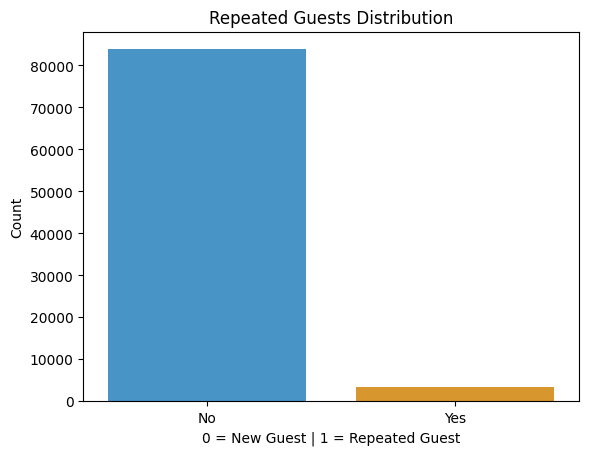

In [ ]:
sns.countplot(
    x='is_repeated_guest',
    data=df,
    palette=['#3498DB', '#F39C12']
)

plt.title('Repeated Guests Distribution')
plt.xlabel('0 = New Guest | 1 = Repeated Guest')
plt.ylabel('Count')

plt.show()

Why: Retention analysis

Insight: Very few repeat customers

Impact: Need loyalty programs

# 10. Special Requests vs Cancellation

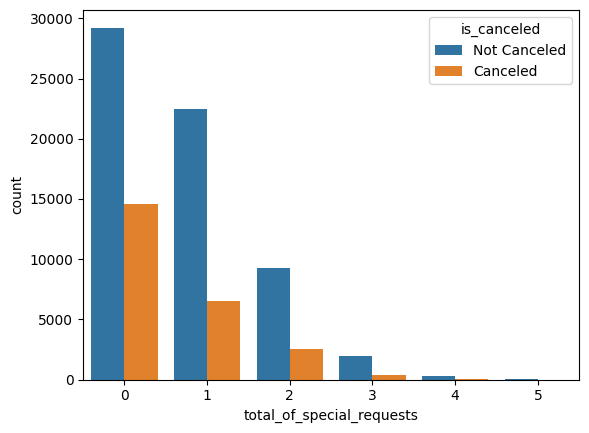

In [ ]:
sns.countplot(x='total_of_special_requests', hue='is_canceled', data=df)
plt.show()

Why: Customer seriousness

Insight: More requests → less cancellation

Impact: Prioritize such customers

# 11. Revenue Leakage (Lost Revenue due to Cancellation)

Lost Revenue: 11478642.98
Actual Revenue: 22967548.15


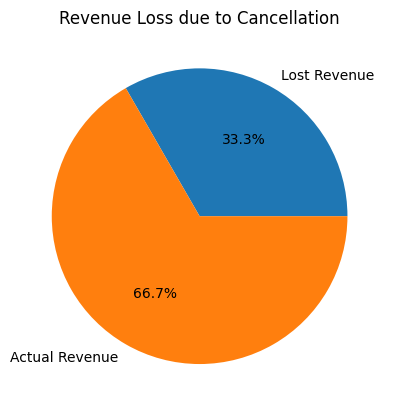

In [ ]:
# Total revenue
df['revenue'] = df['adr'] * df['total_nights']

# Lost revenue (canceled bookings)
lost_revenue = df[df['is_canceled'] == 'Canceled']['revenue'].sum()
actual_revenue = df[df['is_canceled'] == 'Not Canceled']['revenue'].sum()

print("Lost Revenue:", lost_revenue)
print("Actual Revenue:", actual_revenue)

# Plot
labels = ['Lost Revenue', 'Actual Revenue']
values = [lost_revenue, actual_revenue]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Revenue Loss due to Cancellation")
plt.show()

👇

💸 Around 33% revenue is lost due to cancellations

⚠️ High cancellation rate is a major business problem

📉 Leads to empty rooms & poor occupancy planning

🧠 Many bookings are unreliable (especially no-deposit ones)

🎯 Biggest opportunity: reduce cancellations to increase revenue

📊 Even a small reduction in cancellations can boost profit significantly

# 12. Correlation Heatmap

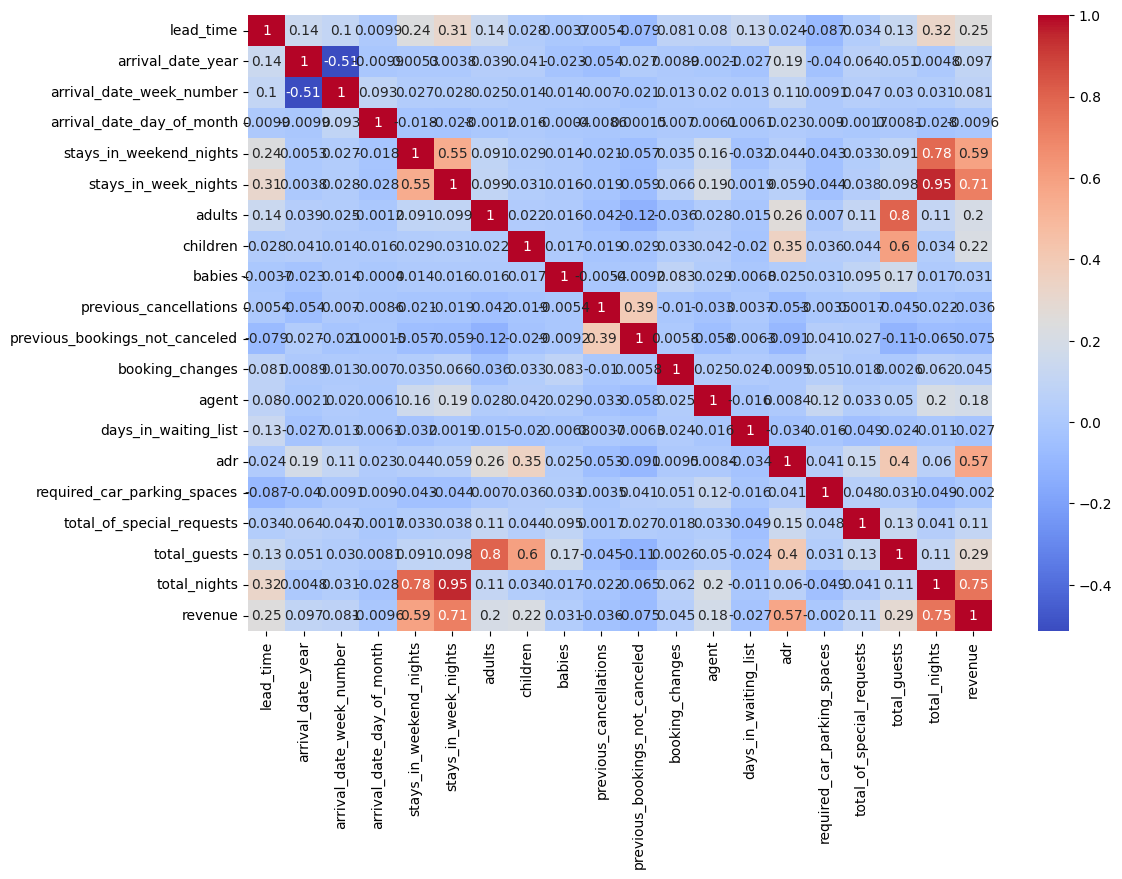

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

Why: Multi-variable relationship

Insight: Identify key influencing variables

Impact: Useful for ML & strategy

# 13. KPI Dashboard (Print Summary)

In [ ]:
print("Total Revenue:", df['revenue'].sum())
print("Cancellation Rate:", df['is_canceled'].value_counts(normalize=True).get('Canceled', 0)*100, "%")
print("Average ADR:", df['adr'].mean())
print("Average Stay:", df['total_nights'].mean())
print("Repeat Guests %:", df['is_repeated_guest'].value_counts(normalize=True).get('Yes', 0)*100, "%")

Total Revenue: 34446191.13
Cancellation Rate: 27.52295681482076 %
Average ADR: 106.45734583682031
Average Stay: 3.628563895034908
Repeat Guests %: 3.8565156083412626 %


# Machine Learning Model Development

# ✅ STEP 1: Convert Target Variable Back to Numeric

In [ ]:
df['is_canceled'] = df['is_canceled'].map({
    'Not Canceled':0,
    'Canceled':1
})

# ✅ STEP 2: Remove Leakage Columns

In [ ]:
drop_cols = [
    'reservation_status',
    'reservation_status_date'
]

df.drop(columns=drop_cols, inplace=True)

# ✅ STEP 3: Select Features & Target

In [ ]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# ✅ STEP 4: Encode Categorical Variables

In [ ]:
X = pd.get_dummies(X, drop_first=True)

# ✅ STEP 5: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ✅ STEP 6: Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🚀 Phase 3: Build ML Models

1️⃣ Logistic Regression

Logistic Regression Accuracy:
0.7980625931445604


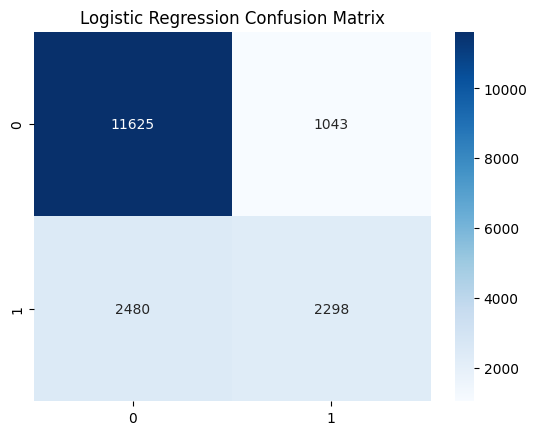

              precision    recall  f1-score   support

           0       0.82      0.92      0.87     12668
           1       0.69      0.48      0.57      4778

    accuracy                           0.80     17446
   macro avg       0.76      0.70      0.72     17446
weighted avg       0.79      0.80      0.79     17446



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_lr))

 2️⃣ Decision Tree

Decision Tree Accuracy:
0.8035079674423937


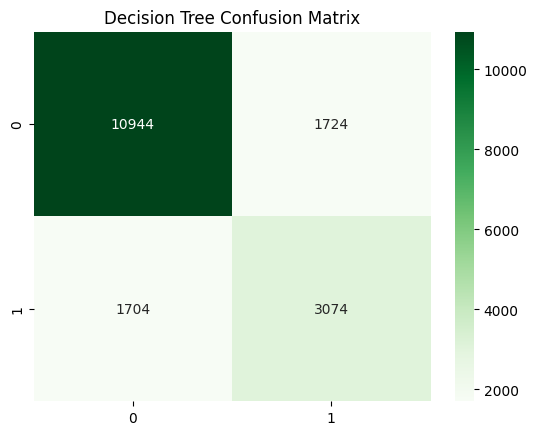

              precision    recall  f1-score   support

           0       0.87      0.86      0.86     12668
           1       0.64      0.64      0.64      4778

    accuracy                           0.80     17446
   macro avg       0.75      0.75      0.75     17446
weighted avg       0.80      0.80      0.80     17446



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_dt))

3️⃣ Random Forest

Random Forest Accuracy:
0.8488478734380374


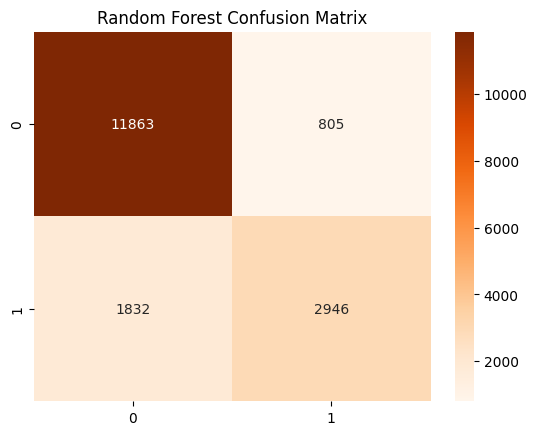

              precision    recall  f1-score   support

           0       0.87      0.94      0.90     12668
           1       0.79      0.62      0.69      4778

    accuracy                           0.85     17446
   macro avg       0.83      0.78      0.80     17446
weighted avg       0.84      0.85      0.84     17446



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Accuracy
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_rf))

4️⃣ XGBoost

In [ ]:
!pip install xgboost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:38:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy:
0.8534907715235585


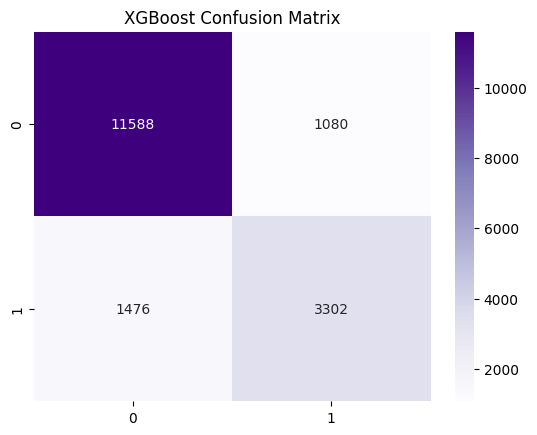

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     12668
           1       0.75      0.69      0.72      4778

    accuracy                           0.85     17446
   macro avg       0.82      0.80      0.81     17446
weighted avg       0.85      0.85      0.85     17446



In [ ]:
from xgboost import XGBClassifier

# Create model
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_train, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
print("XGBoost Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples')
plt.title("XGBoost Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_xgb))

# AUC - ROC SCORES OF ALL MODELS

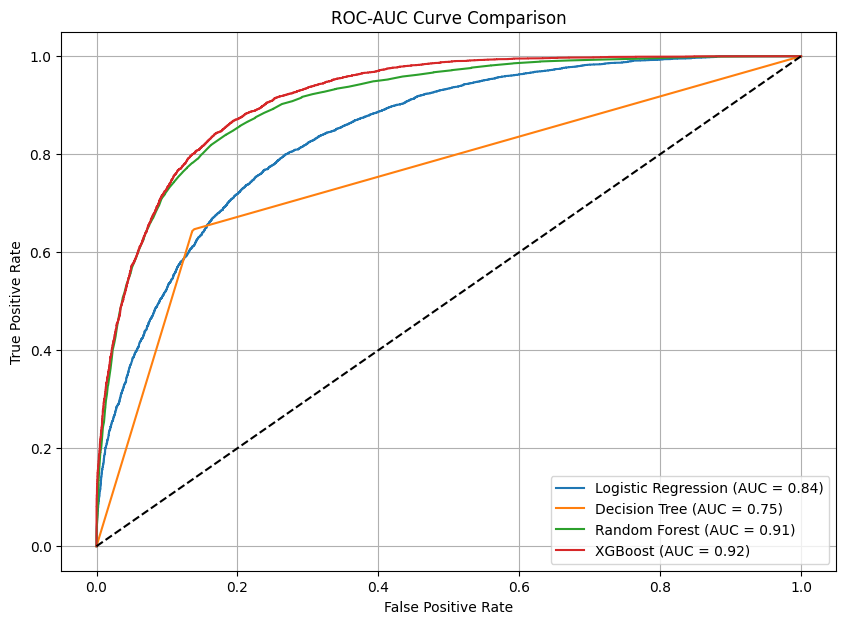

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
lr_probs = lr_model.predict_proba(X_test_scaled)[:,1]
dt_probs = dt_model.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

# ROC Curve values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# AUC Scores
lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# Plot ROC Curves
plt.figure(figsize=(10,7))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_auc:.2f})')

plt.plot(dt_fpr, dt_tpr,
         label=f'Decision Tree (AUC = {dt_auc:.2f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.2f})')

plt.plot(xgb_fpr, xgb_tpr,
         label=f'XGBoost (AUC = {xgb_auc:.2f})')

# Random Guess Line
plt.plot([0,1], [0,1], 'k--')

# Labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')

plt.legend()
plt.grid(True)

plt.show()

* XGBoost achieved the highest ROC-AUC score (0.92), making it the best-performing model.
* Random Forest also performed very well with ROC-AUC of 0.91.
* Logistic Regression showed good baseline performance with ROC-AUC of 0.84.
* Decision Tree had the lowest performance with ROC-AUC of 0.75.
* Ensemble models (Random Forest and XGBoost) outperformed single models.
* The models can effectively help hotels predict booking cancellations and reduce revenue loss.



METRICS - PRECISION RECALL F1_SCORE

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_names = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

metrics_df = pd.DataFrame({
    'Model': model_names,

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

metrics_df = metrics_df.round(2)

metrics_df

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.69,0.48,0.57
1,Decision Tree,0.64,0.64,0.64
2,Random Forest,0.79,0.62,0.69
3,XGBoost,0.75,0.69,0.72


# feature importance graph using random forest

/tmp/ipykernel_8963/3265518807.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


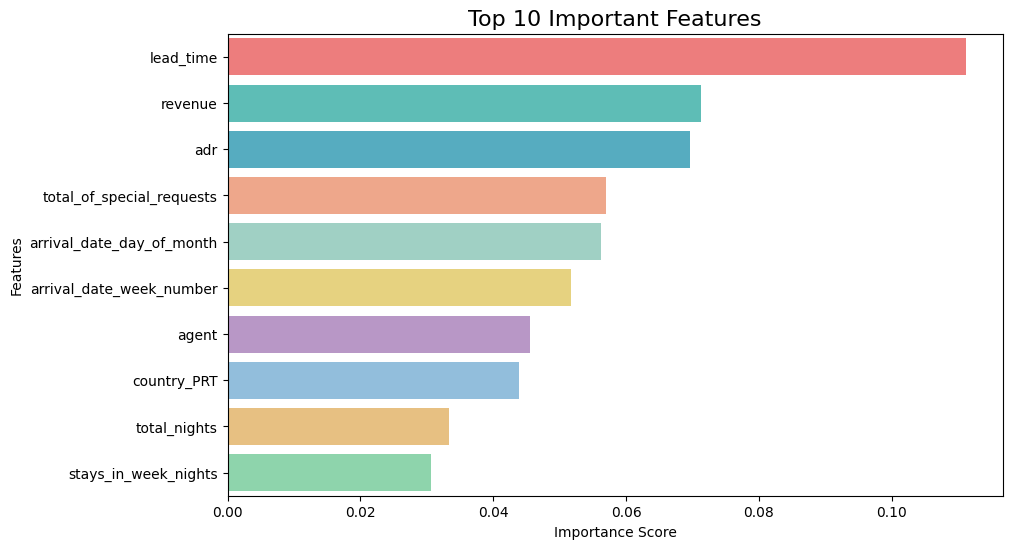

In [ ]:

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

# Sort values
feature_importance = feature_importance.sort_values(ascending=False)

# Top 10 Important Features
top_features = feature_importance.head(10)

# Different colors for each bar
colors = [
    '#FF6B6B',
    '#4ECDC4',
    '#45B7D1',
    '#FFA07A',
    '#98D8C8',
    '#F7DC6F',
    '#BB8FCE',
    '#85C1E9',
    '#F8C471',
    '#82E0AA'
]

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette=colors
)

plt.title("Top 10 Important Features", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [ ]:
# Create Accuracy Comparison Table

model_names = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

# Convert accuracy into percentage
comparison_df['Accuracy'] = comparison_df['Accuracy'] * 100

# Round values
comparison_df['Accuracy'] = comparison_df['Accuracy'].round(2)

# Display table
comparison_df

,Model,Accuracy
0,Logistic Regression,79.81
1,Decision Tree,80.35
2,Random Forest,84.88
3,XGBoost,85.35


In [ ]:
# -----------------------------------------
# Prediction using all 4 ML Models
# -----------------------------------------

# Take one sample from test data
sample_normal = X_test.iloc[[0]]

# For Logistic Regression (scaled input required)
sample_scaled = scaler.transform(sample_normal)

# -------------------------------
# 1. Logistic Regression
# -------------------------------

lr_prediction = lr_model.predict(sample_scaled)

print("Logistic Regression Prediction:")

if lr_prediction[0] == 1:
    print("Canceled")
else:
    print("Not Canceled")


# -------------------------------
# 2. Decision Tree
# -------------------------------

dt_prediction = dt_model.predict(sample_normal)

print("\nDecision Tree Prediction:")

if dt_prediction[0] == 1:
    print("Canceled")
else:
    print("Not Canceled")


# -------------------------------
# 3. Random Forest
# -------------------------------

rf_prediction = rf_model.predict(sample_normal)

print("\nRandom Forest Prediction:")

if rf_prediction[0] == 1:
    print("Canceled")
else:
    print("Not Canceled")


# -------------------------------
# 4. XGBoost
# -------------------------------

xgb_prediction = xgb_model.predict(sample_normal)

print("\nXGBoost Prediction:")

if xgb_prediction[0] == 1:
    print("Canceled")
else:
    print("Not Canceled")

Logistic Regression Prediction:
Not Canceled

Decision Tree Prediction:
Canceled

Random Forest Prediction:
Canceled

XGBoost Prediction:
Not Canceled


In [ ]:
print("""
Final Model Conclusion:

1. XGBoost achieved the highest ROC-AUC score of 0.92,
   making it the best-performing model.

2. Random Forest also performed strongly with ROC-AUC of 0.91.

3. Logistic Regression provided a good baseline performance.

4. Decision Tree showed comparatively lower performance
   and higher risk of overfitting.

5. Machine Learning models can effectively help hotels
   predict booking cancellations and reduce revenue loss.
""")


Final Model Conclusion:

1. XGBoost achieved the highest ROC-AUC score of 0.92,
   making it the best-performing model.

2. Random Forest also performed strongly with ROC-AUC of 0.91.

3. Logistic Regression provided a good baseline performance.

4. Decision Tree showed comparatively lower performance
   and higher risk of overfitting.

5. Machine Learning models can effectively help hotels
   predict booking cancellations and reduce revenue loss.

